# Classification

**Working Example.** Copy this file, rename it, and modify *your* copy.
See earlier notebooks for more information. 

- Author: Denise Case
- Date: 2026-06
- Dataset: Seaborn Penguins
- Target: species
  
Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M3: Classification

This notebook fits a classifier and reports its scores and a confusion matrix.

The analyst decides which metric matters, 
what counts as "good enough," 
and which parameter values to choose.
Code calculates values, but the analyst decides.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

## Overview

This project uses the penguins dataset.
We choose to predict the target `species`.
This target is a **discrete category**, so we have a:

- supervised ML problem (because we've chosen a target)
- a classification problem (because our target is a category)

Customize the overview in your copy to reflect your dataset and choices.

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```


## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## M3. When to Use Classification, and How To Judge It

Use **classification** when the target is a discrete **category**.
For example: which species, spam or not, which of several classes. 
Classification is a form of supervised learning (we have a target).

If the target is a continuous number, that is regression.
If there is no target, that is unsupervised.

We judge a classifier on data it was **not** trained on. 

So we **split** the data into a training set and a test set.
We **fit on train**, and **score on test**. 

Common scores:

- **accuracy** - fraction correct. Misleading when classes are imbalanced.
- **precision / recall** - of the cases called positive, how many were right
  (precision); of the real positives, how many were caught (recall). They trade off.
- **confusion matrix** - the full table of predicted vs. actual, 
  so we can see *which* classes get confused, 
  not just an overall number.

There is no single score that is the right one. 

The right metric depends on what a **mistake costs** in the problem we're addressing.
It is a judgment that the analyst makes and defends.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M03", level="DEBUG")
log_header(LOG, "M03")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-16 17:14:28 | INFO | M03 | === RUN START ===
2026-07-16 17:14:28 | INFO | M03 | project=M03
2026-07-16 17:14:28 | INFO | M03 | repo_dir=ml-03-classification
2026-07-16 17:14:28 | INFO | M03 | python=3.14.0
2026-07-16 17:14:28 | INFO | M03 | os=Windows 11
2026-07-16 17:14:28 | INFO | M03 | shell=powershell
2026-07-16 17:14:28 | INFO | M03 | cwd=notebooks
2026-07-16 17:14:28 | INFO | M03 | github_actions=False
2026-07-16 17:14:28 | INFO | M03 | Confirming installation:
2026-07-16 17:14:28 | INFO | M03 |   python:       3.14.0
2026-07-16 17:14:28 | INFO | M03 |   pandas:       3.0.3
2026-07-16 17:14:28 | INFO | M03 |   numpy:        2.5.1
2026-07-16 17:14:28 | INFO | M03 |   scikit-learn: 1.9.0
2026-07-16 17:14:28 | INFO | M03 |   seaborn:      0.13.2
2026-07-16 17:14:28 | INFO | M03 |   matplotlib:   3.11.0


## Section 2. Load the Data

In [2]:
# === Section 2. Load the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "penguins"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = sns.load_dataset(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

# CUSTOM: ANALYST CHOICE - the categorical target to classify.
TARGET_COL: Final[str] = "species"

# CUSTOM: Numeric features used to predict the target.
FEATURE_COLS: Final[list[str]] = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

2026-07-16 17:14:28 | INFO | M03 | Loading dataset: penguins
2026-07-16 17:14:28 | INFO | M03 | Loaded: 344 rows (instances), 7 columns
2026-07-16 17:14:28 | INFO | M03 | Original rows: 344
2026-07-16 17:14:28 | INFO | M03 | Model rows:    342
2026-07-16 17:14:28 | INFO | M03 | Classes in target 'species': ['Adelie', 'Chinstrap', 'Gentoo']
2026-07-16 17:14:28 | DEBUG | M03 | Class counts:
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.


In [3]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-16 17:14:28 | INFO | M03 | Train instances: 273
2026-07-16 17:14:28 | INFO | M03 | Test instances: 69


## Section 4. Fit a Classifier


ANALYST CHOICE

The model and its parameters are yours to choose. 

This example uses a decision tree with max_depth = MAX_DEPTH. 

Section 6 shows how that choice moves performance; 
here we fit one model and read its scores.


In [4]:
# === Section 4. Fit a Classifier ===


"""
Fit a decision-tree classifier on the training data.

WHY: create -> .fit() -> .predict()
is the same pattern for every scikit-learn estimator.
Learning it once carries to every later model.
"""

# MAX DEPTH is one tunable parameter of the model.

# For a decision tree, max_depth controls complexity:
# - shallow underfits
# - deep overfits

# Section 6 shows the effect; we must choose and defend a value.
# This is typically part of the interative process of model development.
MAX_DEPTH: Final[int] = 3

LOG.info(f"Fitting DecisionTreeClassifier(max_depth={MAX_DEPTH})")

# create a DecisionTreeClassifier with the chosen max_depth and random_state
model = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)

# fit the model on the training data
model.fit(X_train, y_train)

2026-07-16 17:14:28 | INFO | M03 | Fitting DecisionTreeClassifier(max_depth=3)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## Section 5. Evaluate the Model

2026-07-16 17:14:28 | INFO | M03 | Test accuracy: 0.986
2026-07-16 17:14:28 | INFO | M03 | Per-class precision / recall / F1:
2026-07-16 17:14:28 | DEBUG | M03 | 
              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69

2026-07-16 17:14:28 | INFO | M03 | Showing confusion matrix (rows = actual, cols = predicted)


<Figure size 640x480 with 0 Axes>

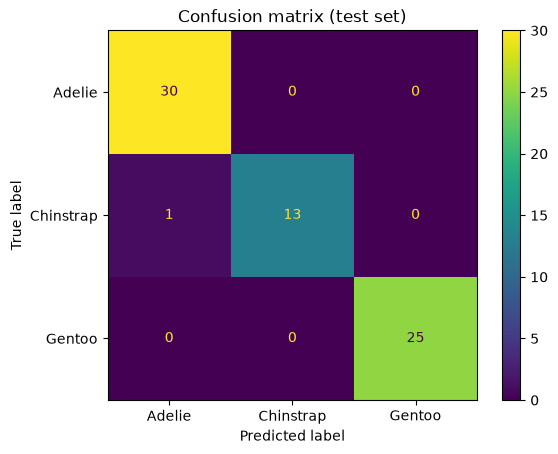

In [5]:
# === Section 5. Evaluate the Model ===

"""Score the model on held-out data and show a confusion matrix.

WHY: A single accuracy number hides which classes get confused.
The report adds precision/recall/F1 per class;
the confusion matrix shows the actual vs. predicted counts.
Read them together.

Code only reports numbers.

It does NOT declare the model good enough.
Whether a model is good enough depends on what a mistake costs
in this specific problem,
which requires analyst judgment.
"""

y_pred: np.ndarray = model.predict(X_test)

# The built in sklearn accuracy_score() function
# returns a numpy Float,
# which is not the same as a native Python float.
# call float() to convert it to a native Python float for better compatibility with other code and libraries.
test_acc: float = float(accuracy_score(y_test, y_pred))
LOG.info(f"Test accuracy: {test_acc:.3f}")

LOG.info("Per-class precision / recall / F1:")
LOG.debug(f"\n{classification_report(y_test, y_pred)}")

LOG.info("Showing confusion matrix (rows = actual, cols = predicted)")

# start a figure
plt.figure()

# create the confusion matrix display
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

# set the title
plt.title("Confusion matrix (test set)")

# show the plot
plt.show()

## Section 6. Parameter Selection Affects Performance

We **sweep** `max_depth`.

We try every value in a range and plot 
accuracy on **train** vs **test** for each one.

Choose a range that starts low (1–2) and 
goes high enough to see the train score 
plateau near 1.0 
while the test score levels off or drops. 

How high that is depends on the dataset.
More features and more complex patterns 
need deeper trees to overfit. 
Start wide and narrow in.

The shape is the lesson:

- very shallow trees **underfit** (both scores low)
- very deep trees **overfit** (train near 1.0, test drops or flattens)

The best depth is where test accuracy is strong 
and the train/test gap is small. 

Finding that is the job of the analyst.

2026-07-16 17:14:28 | DEBUG | M03 |   depth= 1  train=0.791  test=0.797
2026-07-16 17:14:28 | DEBUG | M03 |   depth= 2  train=0.960  test=0.986
2026-07-16 17:14:28 | DEBUG | M03 |   depth= 3  train=0.967  test=0.986
2026-07-16 17:14:28 | DEBUG | M03 |   depth= 4  train=0.989  test=1.000
2026-07-16 17:14:28 | DEBUG | M03 |   depth= 5  train=0.996  test=1.000
2026-07-16 17:14:28 | DEBUG | M03 |   depth= 6  train=0.996  test=1.000
2026-07-16 17:14:28 | DEBUG | M03 |   depth= 7  train=1.000  test=1.000
2026-07-16 17:14:28 | DEBUG | M03 |   depth= 8  train=1.000  test=1.000
2026-07-16 17:14:28 | DEBUG | M03 |   depth= 9  train=1.000  test=1.000
2026-07-16 17:14:28 | DEBUG | M03 |   depth=10  train=1.000  test=1.000
2026-07-16 17:14:28 | DEBUG | M03 |   depth=11  train=1.000  test=1.000
2026-07-16 17:14:28 | DEBUG | M03 |   depth=12  train=1.000  test=1.000


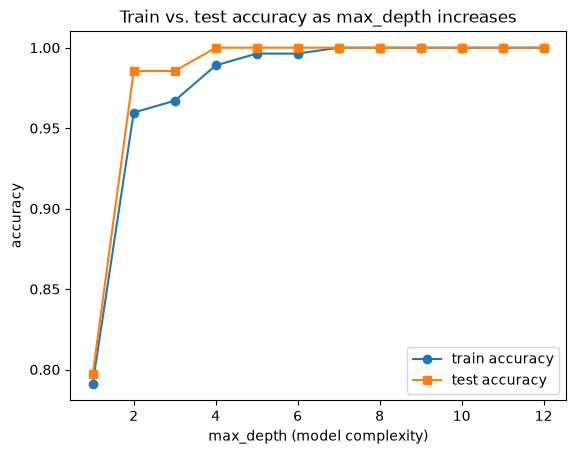

In [6]:
# === Section 6. How Parameter Selection Affects Performance ===

# CUSTOM: ANALYST CHOICE
# for penquins, sweep from 1 to 12 as a good range.
# THIS IS DATA SET DEPENDENT and ANALYST CHOICE.

MAX_SWEEP: Final[int] = 12

# Declare lists to hold the depths and corresponding train/test scores.
depths: list[int] = list(range(1, MAX_SWEEP + 1))
train_scores: list[float] = []
test_scores: list[float] = []

for depth in depths:
    # create and fit a DecisionTreeClassifier with the current depth and random_state
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)

    acc_score_train = accuracy_score(y_train, m.predict(X_train))
    acc_score_test = accuracy_score(y_test, m.predict(X_test))

    # Use float() to convert from numpy Float to native Python float for better compatibility with other code and libraries.
    train_scores.append(float(acc_score_train))
    test_scores.append(float(acc_score_test))

    LOG.debug(
        f"  depth={depth:2d}  train={train_scores[-1]:.3f}  test={test_scores[-1]:.3f}"
    )

# start a new figure
plt.figure()

# plot the train and test scores against the depths
plt.plot(depths, train_scores, marker="o", label="train accuracy")
plt.plot(depths, test_scores, marker="s", label="test accuracy")

# label the axes and add a title and legend
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.title("Train vs. test accuracy as max_depth increases")
plt.legend()

# show the plot
plt.show()

### Interpretation

Read the curves:

- **Underfitting**: where are both train and test accuracy still low?
  (depth is too shallow - the tree cannot capture the pattern)
  
- **Overfitting**: where does train accuracy climb toward 1.0
  while test accuracy levels off or drops?
  (depth is too high - the tree has memorized the training data)
  
- **Sweet spot**: the depth where test accuracy is at its highest
  and the gap between train and test is still small.

For this dataset and split, I might answer:

At depth 1, both scores are low. 
The tree is too shallow to separate the three species. 

At depth 2, both scores jump sharply.
From depth 2 and 3, test accuracy has already reached 0.986. 
At depth 4+, test accuracy is 1.0. 

Train accuracy keeps climbing, reaching near 1.0 by depth 4–5.

I chose depth 3: 

- test accuracy has already reached 0.986, 
  like it did at depth = 2. 
- train accuracy is 0.989, a gap of just 0.003. 
- Adding more depth gains nothing on test and only memorizes training noise.

- Depth 3 is simpler than depth 4 which is good.
- Depth 3 is the same test accuracy as Depth 2, with better training accuracy. 

Depth of 2 or 4 is also defensible. 
The choice between them is up to the analyst to argue.

### Interpretation is Problem-Specific

Numbers will differ when we change the dataset, features, or
random state. 

The **reasoning** pattern remains the same.

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [7]:
# === Python Summary ===

"""Record what was fit and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:   {DATASET_NAME}")
LOG.info(f"Target:    {TARGET_COL}  (classification)")
LOG.info(f"Features:  {FEATURE_COLS}")
LOG.info(f"Model:     DecisionTreeClassifier(max_depth={MAX_DEPTH})")
LOG.info("========================")

2026-07-16 17:14:29 | INFO | M03 | ========================
2026-07-16 17:14:29 | INFO | M03 | SUMMARY
2026-07-16 17:14:29 | INFO | M03 | ========================
2026-07-16 17:14:29 | INFO | M03 | Dataset:   penguins
2026-07-16 17:14:29 | INFO | M03 | Target:    species  (classification)
2026-07-16 17:14:29 | INFO | M03 | Features:  ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
2026-07-16 17:14:29 | INFO | M03 | Model:     DecisionTreeClassifier(max_depth=3)
2026-07-16 17:14:29 | INFO | M03 | ========================



### Custom Narrative

Summarize your work in this Markdown cell in your notebook.

YOUR JUDGMENT (include a summary in docs/index.md also):

- Which metric matters most, and why (what does a mistake cost)?
- Which classes get confused, and does that matter for your use?
- What max_depth did you choose from Section 6, and why?
- Is this model good enough? Good enough for what?

### Next Steps

Summarize your next steps in this Markdown cell in your notebook.


## Task: Make the Notebook Yours (Apply / Extend / Explore)

This is an example.
Copy this notebook and make it your own. 

In your copy:

1. At the beginning, update the Author, the purpose, the target, etc. 
2. Remove any instructions you do not need. 

Try things like the following.

1. **Apply** - Change `TARGET_COL` to `"sex"` (a harder, two-class problem) and
   re-run. Notice accuracy drops; explain in `docs/index.md` why this target is
   harder than species.
2. **Extend** - Swap `DecisionTreeClassifier` for another classifier (e.g.,
   `KNeighborsClassifier` - note it needs scaled features) and compare. Keep the
   same split so the comparison is fair.
3. **Explore** - Build a deliberately imbalanced two-class problem and show that
   high accuracy can hide poor recall on the rare class. Argue which metric you
   would report and why.

## Task: Finalize Your README.md

Include in README.md:

- your project description
- any instructions
- your commands
- a link to key artifacts (including your executed notebook)

When done, you may delete this instruction in your custom notebook.


## Task: Finalize your docs/index.md

In your docs/index.md, include things like:

- Your target.
- Why predicting this target could be useful and for whom.
- Whether ML is a good tool for this problem and why or why not. 
- For example, would a simple rule work better?
- Which features look informative, and which look irrelevant.
- What might 'good enough' mean for this question.

Important:

- There is no threshold that answers these questions automatically.
- Use notebook, README.md, and docs/index.md to share your judgement and your ML skills.


## Task: Final Check

- `README.md` - reflects your description, instructions, commands, and links to your executed notebook.
- `docs/index.md` - reflects your project-specific updates.
- Your GitHub **About** section has a link to your hosted documentation site.
- The executed example notebook AND your custom notebook are available in `notebooks/`.
- Keep this **working example** alongside your custom work until your work has been assessed.
- Ensure your **custom notebook** introduces and narrates **your** custom project.

## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://denisecase.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
